# Lab 03 - Redes Neuronales con TensorFlow/Keras
**Inteligencia Artificial 2026**

En este laboratorio diseñamos redes neuronales fully connected para clasificación y regresión.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, mean_squared_error,
                             mean_absolute_error, r2_score)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


---
## Ejercicio 1: Clasificación de Dígitos (Scikit-Learn digits)

### Carga y exploración del dataset
El dataset `load_digits()` contiene 1,797 imágenes de 8x8 píxeles (64 atributos)
con valores entre 0 y 16. Hay 10 clases (dígitos del 0 al 9).

Shape de X: (1797, 64)
Shape de y: (1797,)
Clases: [0 1 2 3 4 5 6 7 8 9]
Rango de valores: 0.0 - 16.0


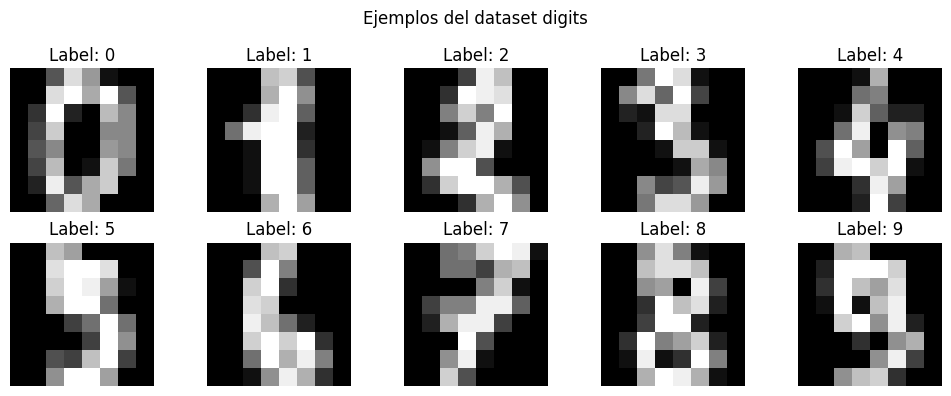

In [2]:
digits = load_digits()
X_digits = digits.data    # shape (1797, 64)
y_digits = digits.target   # shape (1797,)

print("Shape de X:", X_digits.shape)
print("Shape de y:", y_digits.shape)
print("Clases:", np.unique(y_digits))
print("Rango de valores:", X_digits.min(), "-", X_digits.max())

# Visualizar algunos ejemplos
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f"Label: {y_digits[i]}")
    ax.axis('off')
plt.suptitle("Ejemplos del dataset digits")
plt.tight_layout()
plt.show()

### Preprocesamiento

**Normalización:** Dividimos los datos entre 16 (valor máximo de los píxeles)
para llevar los valores al rango [0, 1]. Esto ayuda a que la red converja
más rápido porque los gradientes se mantienen en escalas manejables.

**Etiquetas:** Convertimos las etiquetas a one-hot encoding porque estamos
usando `categorical_crossentropy` como función de pérdida, que espera
vectores de probabilidad como target.

In [3]:
X_norm = X_digits / 16.0  # normalizar al rango [0,1]

# One-hot encoding de las etiquetas
y_onehot = keras.utils.to_categorical(y_digits, num_classes=10)
print("Ejemplo one-hot para el digito", y_digits[0], ":", y_onehot[0])

Ejemplo one-hot para el digito 0 : [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


### Partición Train/Test

Usamos 80% para entrenamiento y 20% para test. Con `stratify=y_digits`
nos aseguramos de que ambos conjuntos mantengan la misma proporción de
cada dígito, lo cual es importante para que el modelo entrene y se evalúe
de forma balanceada.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y_onehot, test_size=0.2, random_state=42, stratify=y_digits
)

print(f"Train: {X_train.shape[0]} muestras")
print(f"Test:  {X_test.shape[0]} muestras")

Train: 1437 muestras
Test:  360 muestras


### Diseño de la Red Neuronal

**Arquitectura:** 2 capas ocultas con 128 y 64 neuronas respectivamente.

- Elegimos 128 neuronas en la primera capa para que la red pueda aprender
  representaciones ricas a partir de los 64 atributos de entrada.
- La segunda capa con 64 neuronas comprime la información antes de la salida.
- **ReLU** en capas ocultas: es la activación más usada porque evita el
  problema del gradiente desvaneciente y es computacionalmente eficiente.
- **Softmax** en la capa de salida: convierte las salidas en probabilidades
  que suman 1, ideal para clasificación multiclase.

**Hiperparámetros:**
- **Pérdida:** `categorical_crossentropy` porque es clasificación multiclase
  con etiquetas one-hot.
- **Optimizador:** Adam con learning rate 0.001 (valor por defecto que
  funciona bien en la mayoría de casos). Adam combina las ventajas de
  RMSProp y momentum.
- **Batch size:** 32, un buen balance entre velocidad y estabilidad del gradiente.
- **Epochs:** 50, suficientes para que la red converja sin sobreajustar.
- **Validación:** 15% del conjunto de entrenamiento para monitorear overfitting.

In [5]:
modelo_clf = keras.Sequential([
    layers.Input(shape=(64,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

modelo_clf.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

modelo_clf.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,226 (67.29 KB)

 Trainable params: 17,226 (67.29 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
historial_clf = modelo_clf.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.15,
    verbose=1
)

Epoch 1/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5659 - loss: 1.8183 - val_accuracy: 0.8009 - val_loss: 1.3118
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8608 - loss: 0.8869 - val_accuracy: 0.8843 - val_loss: 0.6073
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9271 - loss: 0.4326 - val_accuracy: 0.9028 - val_loss: 0.4085
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9378 - loss: 0.2960 - val_accuracy: 0.9259 - val_loss: 0.3036
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9476 - loss: 0.2159 - val_accuracy: 0.9583 - val_loss: 0.2259
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9656 - loss: 0.1657 - val_accuracy: 0.9537 - val_loss: 0.2164
Epoch 7/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9615 - loss: 0.1465 - val_accuracy: 0.9583 - val_loss: 0.2009
Epoch 8/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9697 - loss: 0.1217 - val_accuracy: 0.9537 - val_loss:

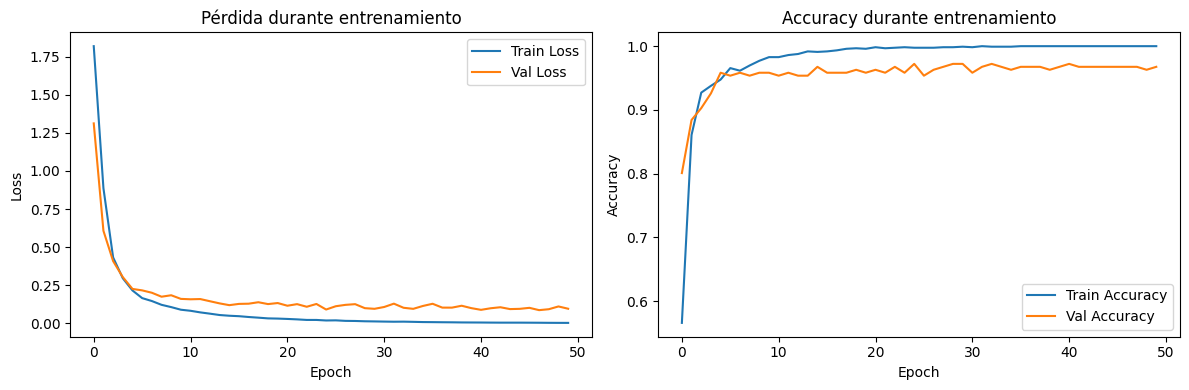

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(historial_clf.history['loss'], label='Train Loss')
ax1.plot(historial_clf.history['val_loss'], label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Pérdida durante entrenamiento')
ax1.legend()

ax2.plot(historial_clf.history['accuracy'], label='Train Accuracy')
ax2.plot(historial_clf.history['val_accuracy'], label='Val Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy durante entrenamiento')
ax2.legend()

plt.tight_layout()
plt.show()

### Evaluación del Modelo

In [8]:
loss_train, acc_train = modelo_clf.evaluate(X_train, y_train, verbose=0)
loss_test, acc_test = modelo_clf.evaluate(X_test, y_test, verbose=0)

print("=== Métricas de Desempeño ===")
print(f"Train - Loss: {loss_train:.4f}, Accuracy: {acc_train:.4f}")
print(f"Test  - Loss: {loss_test:.4f},  Accuracy: {acc_test:.4f}")

# Predicciones
y_pred_prob = modelo_clf.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

print("\n=== Classification Report (Test) ===")
print(classification_report(y_true, y_pred, digits=4))

=== Métricas de Desempeño ===
Train - Loss: 0.0168, Accuracy: 0.9951
Test  - Loss: 0.0660,  Accuracy: 0.9806
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

=== Classification Report (Test) ===
              precision    recall  f1-score   support

           0     1.0000    0.9444    0.9714        36
           1     0.9459    0.9722    0.9589        36
           2     0.9722    1.0000    0.9859        35
           3     1.0000    0.9730    0.9863        37
           4     0.9730    1.0000    0.9863        36
           5     0.9737    1.0000    0.9867        37
           6     0.9722    0.9722    0.9722        36
           7     1.0000    1.0000    1.0000        36
           8     0.9706    0.9429    0.9565        35
           9     1.0000    1.0000    1.0000        36

    accuracy                         0.9806       360
   macro avg     0.9808    0.9805    0.9804       360
weighted avg     0.9808    0.9806    0.9805       360



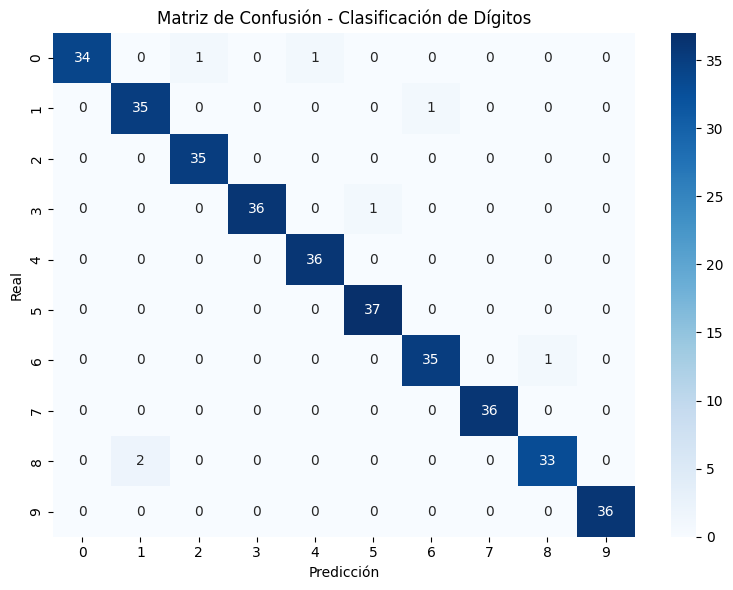

In [9]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión - Clasificación de Dígitos')
plt.tight_layout()
plt.show()

# Se puede observar que los errores más comunes son entre dígitos visualmente
# similares, como el 1 con el 7, o el 3 con el 8.

### Ejemplos de clasificaciones correctas e incorrectas

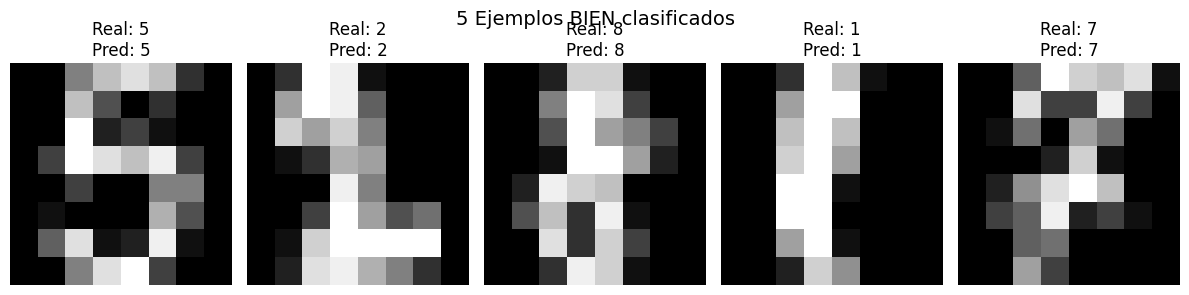

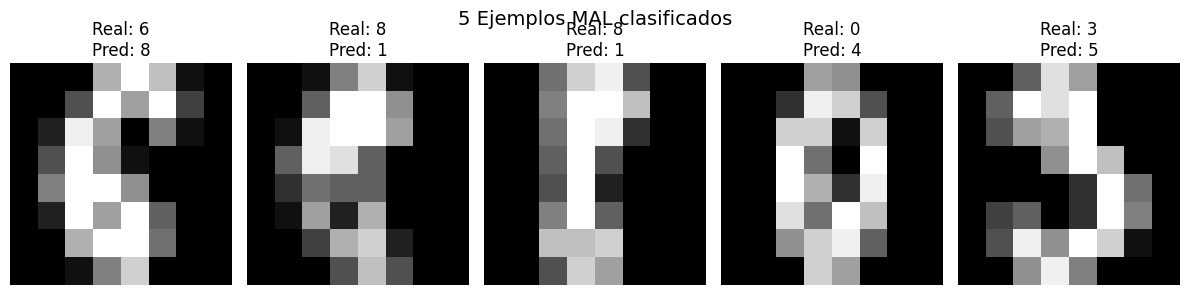

In [10]:
correctos = np.where(y_pred == y_true)[0]
incorrectos = np.where(y_pred != y_true)[0]

# 5 bien clasificados
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
fig.suptitle("5 Ejemplos BIEN clasificados", fontsize=14)
for i, ax in enumerate(axes):
    idx = correctos[i]
    img = X_test[idx].reshape(8, 8)
    ax.imshow(img, cmap='gray')
    ax.set_title(f"Real: {y_true[idx]}\nPred: {y_pred[idx]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

# 5 mal clasificados
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
fig.suptitle("5 Ejemplos MAL clasificados", fontsize=14)
n_mostrar = min(5, len(incorrectos))
for i in range(n_mostrar):
    idx = incorrectos[i]
    img = X_test[idx].reshape(8, 8)
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"Real: {y_true[idx]}\nPred: {y_pred[idx]}")
    axes[i].axis('off')
# si hay menos de 5 errores, ocultar ejes restantes
for i in range(n_mostrar, 5):
    axes[i].axis('off')
plt.tight_layout()
plt.show()

if len(incorrectos) < 5:
    print(f"Nota: solo se encontraron {len(incorrectos)} errores de clasificación.")

---
## Ejercicio 2: Regresión de Precios (California Housing)

### Carga y exploración del dataset
El dataset `fetch_california_housing()` contiene 20,640 muestras con
8 atributos socioeconómicos y geográficos. El target es el valor medio
de las viviendas (en cientos de miles de dólares).

In [11]:
housing = fetch_california_housing()
X_housing = housing.data
y_housing = housing.target

print("Shape de X:", X_housing.shape)
print("Shape de y:", y_housing.shape)
print("Atributos:", housing.feature_names)
print("\nEstadísticas del target:")
print(f"  Min: {y_housing.min():.2f}, Max: {y_housing.max():.2f}, Media: {y_housing.mean():.2f}")

Shape de X: (20640, 8)
Shape de y: (20640,)
Atributos: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Estadísticas del target:
  Min: 0.15, Max: 5.00, Media: 2.07


### Preprocesamiento

**Estandarización con StandardScaler:** Los atributos tienen escalas muy
diferentes (por ejemplo, ingresos medios vs latitud). Sin estandarizar,
los atributos con valores grandes dominarían el entrenamiento y los
gradientes podrían explotar. StandardScaler transforma cada atributo
para que tenga media 0 y desviación estándar 1.

In [12]:
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_housing, y_housing, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_h = scaler.fit_transform(X_train_h)
X_test_h = scaler.transform(X_test_h)  # solo transform, no fit

print(f"Train: {X_train_h.shape[0]} muestras")
print(f"Test:  {X_test_h.shape[0]} muestras")
print(f"\nMedia despues de escalar (train): {X_train_h.mean(axis=0).round(4)}")
print(f"Std despues de escalar (train):   {X_train_h.std(axis=0).round(4)}")

Train: 16512 muestras
Test:  4128 muestras

Media despues de escalar (train): [-0. -0.  0. -0. -0. -0.  0. -0.]
Std despues de escalar (train):   [1. 1. 1. 1. 1. 1. 1. 1.]


### Diseño de la Red Neuronal

**Arquitectura:** 3 capas ocultas con 64, 32 y 16 neuronas.

- Usamos una red más profunda porque los datos de California Housing tienen
  relaciones no lineales complejas entre variables socioeconómicas y
  geográficas (ingreso, ubicación, edad de vivienda, etc.).
- La estructura decreciente (64→32→16) permite que la red vaya extrayendo
  características cada vez más abstractas.
- **ReLU** en capas ocultas por las mismas razones del ejercicio 1.
- **Sin activación en la capa de salida** (lineal) porque es un problema
  de regresión y necesitamos predecir valores continuos sin restricción.

**Hiperparámetros:**
- **Pérdida:** MSE (Mean Squared Error) porque penaliza más los errores
  grandes, lo cual es deseable en predicción de precios.
- **Optimizador:** Adam con learning rate 0.001.
- **Batch size:** 32.
- **Epochs:** 100, ya que el dataset es más grande y la red necesita
  más iteraciones para converger.
- **Validación:** 15% del entrenamiento.

In [13]:
modelo_reg = keras.Sequential([
    layers.Input(shape=(8,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)   # salida lineal para regresion
])

modelo_reg.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

modelo_reg.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
historial_reg = modelo_reg.fit(
    X_train_h, y_train_h,
    epochs=100,
    batch_size=32,
    validation_split=0.15,
    verbose=1
)

Epoch 1/100
439/439 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.1057 - mae: 0.6429 - val_loss: 0.4332 - val_mae: 0.4550
Epoch 2/100
439/439 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3902 - mae: 0.4411 - val_loss: 0.4086 - val_mae: 0.4564
Epoch 3/100
439/439 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3550 - mae: 0.4244 - val_loss: 0.3882 - val_mae: 0.4442
Epoch 4/100
439/439 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3412 - mae: 0.4138 - val_loss: 0.3709 - val_mae: 0.4265
Epoch 5/100
439/439 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3286 - mae: 0.4039 - val_loss: 0.3571 - val_mae: 0.4098
Epoch 6/100
439/439 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3183 - mae: 0.3965 - val_loss: 0.3553 - val_mae: 0.4046
Epoch 7/100
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3114 - mae: 0.3893 - val_loss: 0.3680 - val_mae: 0.4249
Epoch 8/100
439/439 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3055 - mae: 0.3861 - val_loss: 0.3454 - val_mae: 0.4071
Epoch 9/100
439/439 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/

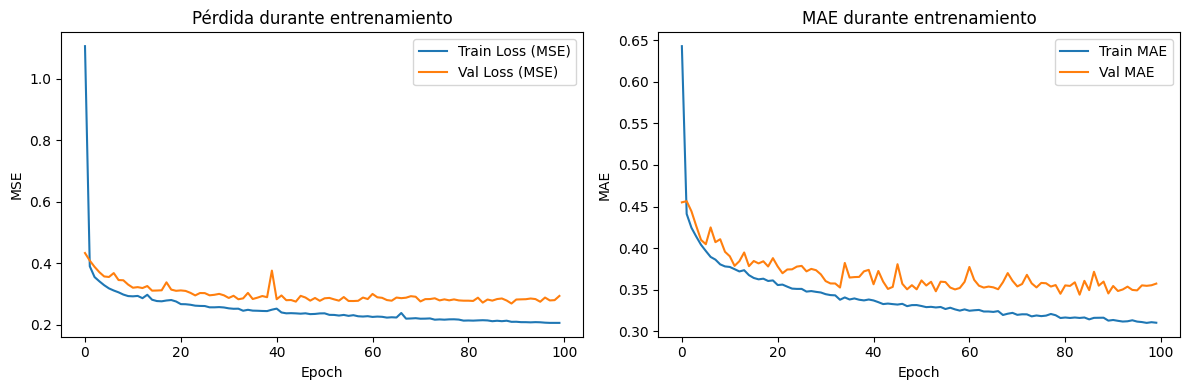

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(historial_reg.history['loss'], label='Train Loss (MSE)')
ax1.plot(historial_reg.history['val_loss'], label='Val Loss (MSE)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE')
ax1.set_title('Pérdida durante entrenamiento')
ax1.legend()

ax2.plot(historial_reg.history['mae'], label='Train MAE')
ax2.plot(historial_reg.history['val_mae'], label='Val MAE')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MAE')
ax2.set_title('MAE durante entrenamiento')
ax2.legend()

plt.tight_layout()
plt.show()

### Evaluación del Modelo

In [16]:
loss_train_h, mae_train_h = modelo_reg.evaluate(X_train_h, y_train_h, verbose=0)
loss_test_h, mae_test_h = modelo_reg.evaluate(X_test_h, y_test_h, verbose=0)

y_pred_train_h = modelo_reg.predict(X_train_h).flatten()
y_pred_test_h = modelo_reg.predict(X_test_h).flatten()

mse_train = mean_squared_error(y_train_h, y_pred_train_h)
mse_test = mean_squared_error(y_test_h, y_pred_test_h)
mae_train_calc = mean_absolute_error(y_train_h, y_pred_train_h)
mae_test_calc = mean_absolute_error(y_test_h, y_pred_test_h)
r2_train = r2_score(y_train_h, y_pred_train_h)
r2_test = r2_score(y_test_h, y_pred_test_h)
rmse_train = np.sqrt(mse_train)
rmse_test = np.sqrt(mse_test)

print("=== Métricas de Desempeño - Regresión ===")
print(f"{'Métrica':<12} {'Train':>10} {'Test':>10}")
print("-" * 34)
print(f"{'MSE':<12} {mse_train:>10.4f} {mse_test:>10.4f}")
print(f"{'RMSE':<12} {rmse_train:>10.4f} {rmse_test:>10.4f}")
print(f"{'MAE':<12} {mae_train_calc:>10.4f} {mae_test_calc:>10.4f}")
print(f"{'R²':<12} {r2_train:>10.4f} {r2_test:>10.4f}")

516/516 ━━━━━━━━━━━━━━━━━━━━ 0s 377us/step
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 473us/step
=== Métricas de Desempeño - Regresión ===
Métrica           Train       Test
----------------------------------
MSE              0.2248     0.2792
RMSE             0.4741     0.5284
MAE              0.3189     0.3474
R²               0.8318     0.7869


### Scatter Plot: Predicciones vs Valores Reales

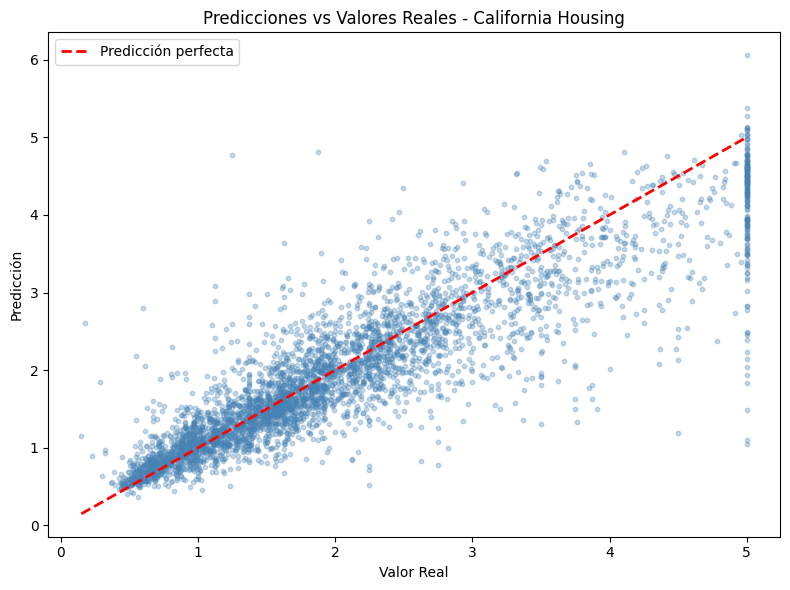

In [17]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_h, y_pred_test_h, alpha=0.3, s=10, color='steelblue')
plt.plot([y_test_h.min(), y_test_h.max()],
         [y_test_h.min(), y_test_h.max()],
         'r--', linewidth=2, label='Predicción perfecta')
plt.xlabel('Valor Real')
plt.ylabel('Predicción')
plt.title('Predicciones vs Valores Reales - California Housing')
plt.legend()
plt.tight_layout()
plt.show()

### 3 Predicciones con observaciones nuevas

Creamos 3 observaciones ficticias que no forman parte del dataset original.
Los atributos son: MedInc, HouseAge, AveRooms, AveBedrms, Population,
AveOccup, Latitude, Longitude.

In [18]:
nuevas_observaciones = np.array([
    [4.5, 30, 5.0, 1.1, 800, 3.0, 34.05, -118.25],   # zona de Los Angeles
    [8.0, 15, 6.5, 1.0, 1200, 2.5, 37.78, -122.42],   # zona de San Francisco
    [3.0, 40, 4.5, 1.2, 600, 3.5, 33.95, -117.40],     # zona de Riverside
])

nuevas_escaladas = scaler.transform(nuevas_observaciones)
predicciones = modelo_reg.predict(nuevas_escaladas).flatten()

print("=== Predicciones para 3 observaciones nuevas ===")
nombres_zona = ["Los Angeles", "San Francisco", "Riverside"]
for i in range(3):
    print(f"\nObservación {i+1} ({nombres_zona[i]}):")
    print(f"  Atributos: MedInc={nuevas_observaciones[i,0]}, "
          f"HouseAge={nuevas_observaciones[i,1]}, "
          f"AveRooms={nuevas_observaciones[i,2]:.1f}, "
          f"AveBedrms={nuevas_observaciones[i,3]:.1f}")
    print(f"  Population={nuevas_observaciones[i,4]:.0f}, "
          f"AveOccup={nuevas_observaciones[i,5]:.1f}, "
          f"Lat={nuevas_observaciones[i,6]:.2f}, "
          f"Lon={nuevas_observaciones[i,7]:.2f}")
    print(f"  Precio predicho: {predicciones[i]:.4f} "
          f"(≈ ${predicciones[i]*100000:,.0f} USD)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
=== Predicciones para 3 observaciones nuevas ===

Observación 1 (Los Angeles):
  Atributos: MedInc=4.5, HouseAge=30.0, AveRooms=5.0, AveBedrms=1.1
  Population=800, AveOccup=3.0, Lat=34.05, Lon=-118.25
  Precio predicho: 2.2120 (≈ $221,202 USD)

Observación 2 (San Francisco):
  Atributos: MedInc=8.0, HouseAge=15.0, AveRooms=6.5, AveBedrms=1.0
  Population=1200, AveOccup=2.5, Lat=37.78, Lon=-122.42
  Precio predicho: 3.8914 (≈ $389,142 USD)

Observación 3 (Riverside):
  Atributos: MedInc=3.0, HouseAge=40.0, AveRooms=4.5, AveBedrms=1.2
  Population=600, AveOccup=3.5, Lat=33.95, Lon=-117.40
  Precio predicho: 0.8735 (≈ $87,353 USD)


---
## Conclusiones

**Ejercicio 1 (Clasificación):** La red neuronal con 2 capas ocultas (128, 64)
logró una buena accuracy en el dataset de dígitos. La matriz de confusión
muestra que los errores ocurren principalmente entre dígitos visualmente
parecidos (1-7, 3-8), lo cual tiene sentido dado que las imágenes son de
solo 8x8 píxeles.

**Ejercicio 2 (Regresión):** La red con 3 capas ocultas (64, 32, 16) logra
capturar las relaciones entre las variables socioeconómicas y el precio de
vivienda. El scatter plot muestra una correlación clara entre predicciones
y valores reales, aunque hay mayor dispersión en precios altos. Las
predicciones para observaciones nuevas son coherentes con las zonas
geográficas seleccionadas.